## ViT

In [2]:
import torch
from PIL import Image
from torchvision.models import vision_transformer

from zennit.image import imgify
from zennit.composites import LayerMapComposite
import zennit.rules as z_rules

from lxt.efficient import monkey_patch, monkey_patch_zennit

monkey_patch(vision_transformer, verbose=True)
monkey_patch_zennit(verbose=True)

/home/jky/xai-vdoc-retrieval-benchmark/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Patched GELU
Patched LayerNorm
Patched MultiheadAttention
Patched Zennit BasicHook's forward
Patched Zennit BasicHook's backward


In [3]:
from io import BytesIO
import requests

def get_vit_imagenet(device="cuda"):
    """
    Load a pre-trained Vision Transformer (ViT) model with ImageNet weights.

    Parameters:
    device (str): Device to load the model on ('cuda' or 'cpu')

    Returns:
    tuple: (model, weights) - The ViT model and its pre-trained weights
    """
    weights =vision_transformer.ViT_B_16_Weights.IMAGENET1K_V1
    model = vision_transformer.vit_b_16(weights=weights)
    model.eval()
    model.to(device)

    # Deactivate gradients on parameters to save memory
    for param in model.parameters():
        param.requires_grad = False

    return model, weights

# Load the pre-trained ViT model
model_vit, weights = get_vit_imagenet()

# Load and preprocess the input image
image_url = "https://qianwen-res.oss-cn-beijing.aliyuncs.com/Qwen-VL/assets/demo.jpeg" 
image = Image.open(BytesIO(requests.get(image_url).content)).convert("RGB")
input_tensor = weights.transforms()(image).unsqueeze(0).to("cuda")

In [4]:
image.size

(2048, 1365)

In [5]:
model_vit

VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_a

In [6]:
input_tensor.shape

torch.Size([1, 3, 224, 224])

In [7]:
# Define rules for the Conv2d and Linear layers using 'zennit'
conv_gamma = 100
lin_gamma = 0.05
# LayerMapComposite maps specific layer types to specific LRP rule implementations
zennit_comp = LayerMapComposite([
    (torch.nn.Conv2d, z_rules.Gamma(conv_gamma)),
    (torch.nn.Linear, z_rules.Gamma(lin_gamma)),
])

# Register the composite rules with the model_vit
zennit_comp.register(model_vit)

# Forward pass with gradient tracking enabled
y = model_vit(input_tensor.requires_grad_())

# Get the top 5 predictions
_, top5_classes = torch.topk(y, 5, dim=1)
top5_classes = top5_classes.squeeze(0).tolist()

# Get the class labels
labels = weights.meta["categories"]
top5_labels = [labels[class_idx] for class_idx in top5_classes]

# Print the top 5 predictions and their labels
for i, class_idx in enumerate(top5_classes):
    print(f'Top {i+1} predicted class: {class_idx}, label: {top5_labels[i]}')

# Backward pass for the highest probability class
# This initiates the LRP computation through the network
y[0, top5_classes[0]].backward()

# Remove the registered composite to prevent interference in future iterations
zennit_comp.remove()

# Calculate the relevance by computing Input*Gradient
# This is the final step of LRP to get the pixel-wise explanation
heatmap = (input_tensor * input_tensor.grad).sum(1)

# Normalize relevance between [-1, 1] for plotting
heatmap = heatmap / abs(heatmap).max()

Top 1 predicted class: 176, label: Saluki
Top 2 predicted class: 250, label: Siberian husky
Top 3 predicted class: 207, label: golden retriever
Top 4 predicted class: 248, label: Eskimo dog
Top 5 predicted class: 208, label: Labrador retriever


In [8]:
heatmap.shape

torch.Size([1, 224, 224])

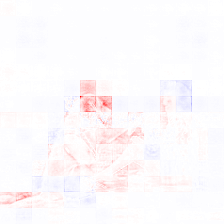

In [9]:
imgify(heatmap.detach().cpu().numpy(), vmin=-1, vmax=1)

## Qwen VL


In [ ]:
import torch
from transformers import BitsAndBytesConfig
from transformers import AutoProcessor, Qwen2_5_VLForConditionalGeneration
from transformers.utils.import_utils import is_flash_attn_2_available

model_id = "Qwen/Qwen2.5-VL-3B-Instruct"

def load_qwen_model(model_id="Qwen/Qwen2.5-VL-3B-Instruct"):

    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.float16,
    )

    processor = AutoProcessor.from_pretrained(model_id)

    model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
        model_id,
        #quantization_config=bnb_config,
        # low_cpu_mem_usage=True,
        dtype="auto",          # keep weights in fp16 after dequant chunks
        device_map="auto",                  # split across GPU/CPU automatically
        # attn_implementation=(
        #     "flash_attention_2" if is_flash_attn_2_available() else None
        # ),
        attn_implementation=None,
    )
    return model, processor


/home/jky/xai-vdoc-retrieval-benchmark/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
model_id = "Qwen/Qwen2.5-VL-3B-Instruct"
model, processor = load_qwen_model(model_id)
model.eval()

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. Note that this behavior will be extended to all models in a future release.
Loading checkpoint shards: 100%|██████████| 2/2 [00:02<00:00,  1.29s/it]


Qwen2_5_VLForConditionalGeneration(
  (model): Qwen2_5_VLModel(
    (visual): Qwen2_5_VisionTransformerPretrainedModel(
      (patch_embed): Qwen2_5_VisionPatchEmbed(
        (proj): Conv3d(3, 1280, kernel_size=(2, 14, 14), stride=(2, 14, 14), bias=False)
      )
      (rotary_pos_emb): Qwen2_5_VisionRotaryEmbedding()
      (blocks): ModuleList(
        (0-31): 32 x Qwen2_5_VLVisionBlock(
          (norm1): Qwen2RMSNorm((1280,), eps=1e-06)
          (norm2): Qwen2RMSNorm((1280,), eps=1e-06)
          (attn): Qwen2_5_VLVisionAttention(
            (qkv): Linear(in_features=1280, out_features=3840, bias=True)
            (proj): Linear(in_features=1280, out_features=1280, bias=True)
          )
          (mlp): Qwen2_5_VLMLP(
            (gate_proj): Linear(in_features=1280, out_features=3420, bias=True)
            (up_proj): Linear(in_features=1280, out_features=3420, bias=True)
            (down_proj): Linear(in_features=3420, out_features=1280, bias=True)
            (act_fn): SiLUAc

In [3]:
processor

Qwen2_5_VLProcessor:
- image_processor: Qwen2VLImageProcessorFast {
  "crop_size": null,
  "data_format": "channels_first",
  "default_to_square": true,
  "device": null,
  "disable_grouping": null,
  "do_center_crop": null,
  "do_convert_rgb": true,
  "do_normalize": true,
  "do_pad": null,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.48145466,
    0.4578275,
    0.40821073
  ],
  "image_processor_type": "Qwen2VLImageProcessorFast",
  "image_std": [
    0.26862954,
    0.26130258,
    0.27577711
  ],
  "input_data_format": null,
  "max_pixels": 12845056,
  "merge_size": 2,
  "min_pixels": 3136,
  "pad_size": null,
  "patch_size": 14,
  "processor_class": "Qwen2_5_VLProcessor",
  "resample": 3,
  "rescale_factor": 0.00392156862745098,
  "return_tensors": null,
  "size": {
    "longest_edge": 12845056,
    "shortest_edge": 3136
  },
  "temporal_patch_size": 2
}

- tokenizer: Qwen2TokenizerFast(name_or_path='Qwen/Qwen2.5-VL-3B-Instruct', vocab_size=151643, model_max

In [4]:
model.config

Qwen2_5_VLConfig {
  "architectures": [
    "Qwen2_5_VLForConditionalGeneration"
  ],
  "attention_dropout": 0.0,
  "bos_token_id": 151643,
  "dtype": "bfloat16",
  "eos_token_id": 151645,
  "hidden_act": "silu",
  "hidden_size": 2048,
  "image_token_id": 151655,
  "initializer_range": 0.02,
  "intermediate_size": 11008,
  "max_position_embeddings": 128000,
  "max_window_layers": 70,
  "model_type": "qwen2_5_vl",
  "num_attention_heads": 16,
  "num_hidden_layers": 36,
  "num_key_value_heads": 2,
  "rms_norm_eps": 1e-06,
  "rope_scaling": {
    "mrope_section": [
      16,
      24,
      24
    ],
    "rope_type": "default",
    "type": "default"
  },
  "rope_theta": 1000000.0,
  "sliding_window": 32768,
  "text_config": {
    "_name_or_path": "Qwen/Qwen2.5-VL-3B-Instruct",
    "architectures": [
      "Qwen2_5_VLForConditionalGeneration"
    ],
    "attention_dropout": 0.0,
    "bos_token_id": 151643,
    "dtype": "bfloat16",
    "eos_token_id": 151645,
    "hidden_act": "silu",
    "

In [5]:
print(model.language_model)

Qwen2_5_VLTextModel(
  (embed_tokens): Embedding(151936, 2048)
  (layers): ModuleList(
    (0-35): 36 x Qwen2_5_VLDecoderLayer(
      (self_attn): Qwen2_5_VLAttention(
        (q_proj): Linear(in_features=2048, out_features=2048, bias=True)
        (k_proj): Linear(in_features=2048, out_features=256, bias=True)
        (v_proj): Linear(in_features=2048, out_features=256, bias=True)
        (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
        (rotary_emb): Qwen2_5_VLRotaryEmbedding()
      )
      (mlp): Qwen2MLP(
        (gate_proj): Linear(in_features=2048, out_features=11008, bias=False)
        (up_proj): Linear(in_features=2048, out_features=11008, bias=False)
        (down_proj): Linear(in_features=11008, out_features=2048, bias=False)
        (act_fn): SiLUActivation()
      )
      (input_layernorm): Qwen2RMSNorm((2048,), eps=1e-06)
      (post_attention_layernorm): Qwen2RMSNorm((2048,), eps=1e-06)
    )
  )
  (norm): Qwen2RMSNorm((2048,), eps=1e-06)
  (rota

In [6]:
print(model.visual)

Qwen2_5_VisionTransformerPretrainedModel(
  (patch_embed): Qwen2_5_VisionPatchEmbed(
    (proj): Conv3d(3, 1280, kernel_size=(2, 14, 14), stride=(2, 14, 14), bias=False)
  )
  (rotary_pos_emb): Qwen2_5_VisionRotaryEmbedding()
  (blocks): ModuleList(
    (0-31): 32 x Qwen2_5_VLVisionBlock(
      (norm1): Qwen2RMSNorm((1280,), eps=1e-06)
      (norm2): Qwen2RMSNorm((1280,), eps=1e-06)
      (attn): Qwen2_5_VLVisionAttention(
        (qkv): Linear(in_features=1280, out_features=3840, bias=True)
        (proj): Linear(in_features=1280, out_features=1280, bias=True)
      )
      (mlp): Qwen2_5_VLMLP(
        (gate_proj): Linear(in_features=1280, out_features=3420, bias=True)
        (up_proj): Linear(in_features=1280, out_features=3420, bias=True)
        (down_proj): Linear(in_features=3420, out_features=1280, bias=True)
        (act_fn): SiLUActivation()
      )
    )
  )
  (merger): Qwen2_5_VLPatchMerger(
    (ln_q): Qwen2RMSNorm((1280,), eps=1e-06)
    (mlp): Sequential(
      (0): Lin

In [7]:
from PIL import Image
import requests
from io import BytesIO

from qwen_vl_utils import process_vision_info

def get_inputs(processor):
    image_url = "https://qianwen-res.oss-cn-beijing.aliyuncs.com/Qwen-VL/assets/demo.jpeg" 
    image = Image.open(BytesIO(requests.get(image_url).content)).convert("RGB")

    # Construct the multimodal conversation prompt
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": "Describe the main scene and the object being pointed at."},
            ],
        }
    ]

    # Preparation for inference
    text = processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    image_inputs, _ = process_vision_info(messages)
    inputs = processor(
        text=[text],
        images=image_inputs,
        videos=None,
        padding=True,
        return_tensors="pt",
    )
    return inputs, image

In [8]:
inputs, image = get_inputs(processor)

In [9]:
inputs = inputs.to(model.device)

In [10]:
def get_target(inputs, model):
    inputs = inputs.to(model.device)
    model.eval()

    # 1) Decide a target sequence (reference or self-generated)
    with torch.no_grad():
        gen = model.generate(**inputs, max_new_tokens=32)
    # Use only the newly generated continuation as target
    target = gen[0, inputs['input_ids'].shape[1]:]          # tensor of target ids
    T = target.shape[0]
    return target, gen

In [13]:
target, gen = get_target(inputs, model)
target

KeyboardInterrupt: 

In [16]:
generated_ids_trimmed = [
    out_ids[len(in_ids) :] for in_ids, out_ids in zip(inputs.input_ids, gen)
]
output_text = processor.batch_decode(
    generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
)
print(output_text)

[" you's when/这些所在这的图 �的比很 or的事者 phrase the,和你起's �律 l判断（ �と '"]


In [17]:
generated_ids_trimmed

[tensor([   498,    594,    979,     14, 100001,  31838, 102332,   9370,  28029,
          18137,   9370,  56006,  99165,    476,   9370,  29826,  28946,  17133,
            279,     11,  33108,  56568,  71618,    594,   4891,  99499,    326,
         104317,   9909,  49434,  19182,    364], device='cuda:0')]

In [11]:
gen.shape

torch.Size([1, 3641])

In [10]:
torch.cuda.empty_cache()

In [39]:
from torchinfo import summary

summary(model.visual, input_data=(
                        #inputs["input_ids"],
                           #inputs["attention_mask"], 
                           inputs["pixel_values"], 
                           inputs["image_grid_thw"]
                           ),
                batch_dim=1,
        depth=5
        )

Layer (type:depth-idx)                             Output Shape              Param #
Qwen2_5_VisionTransformerPretrainedModel           [3577, 2048]              --
├─Qwen2_5_VisionPatchEmbed: 1-1                    [14308, 1280]             --
│    └─Conv3d: 2-1                                 [14308, 1280, 1, 1, 1]    (1,505,280)
├─Qwen2_5_VisionRotaryEmbedding: 1-2               [146, 20]                 --
├─ModuleList: 1-3                                  --                        --
│    └─Qwen2_5_VLVisionBlock: 2-2                  [14308, 1280]             --
│    │    └─Qwen2RMSNorm: 3-1                      [14308, 1280]             (1,280)
│    │    └─Qwen2_5_VLVisionAttention: 3-2         [14308, 1280]             --
│    │    │    └─Linear: 4-1                       [14308, 3840]             (4,919,040)
│    │    │    └─Linear: 4-2                       [14308, 1280]             (1,639,680)
│    │    └─Qwen2RMSNorm: 3-3                      [14308, 1280]             (1,280

In [40]:
from torchinfo import summary

summary(model.language_model, input_data=(
                                inputs["input_ids"],
                                inputs["attention_mask"], 
                                #inputs["pixel_values"], 
                                #inputs["image_grid_thw"]
                                ),
                batch_dim=1,
        depth=5
        )

Layer (type:depth-idx)                        Output Shape              Param #
Qwen2_5_VLTextModel                           [[1]]                     --
├─Embedding: 1-1                              [1, 3609, 2048]           (311,164,928)
├─Qwen2_5_VLRotaryEmbedding: 1-2              [3, 1, 3609, 128]         --
├─ModuleList: 1-3                             --                        --
│    └─Qwen2_5_VLDecoderLayer: 2-1            [1, 1, 2048]              --
│    │    └─Qwen2RMSNorm: 3-1                 [1, 3609, 2048]           (2,048)
│    │    └─Qwen2_5_VLAttention: 3-2          [1, 1, 2048]              --
│    │    │    └─Linear: 4-1                  [1, 3609, 2048]           (4,196,352)
│    │    │    └─Linear: 4-2                  [1, 3609, 256]            (524,544)
│    │    │    └─Linear: 4-3                  [1, 3609, 256]            (524,544)
│    │    │    └─Linear: 4-4                  [1, 3609, 2048]           (4,194,304)
│    │    └─Qwen2RMSNorm: 3-3                 [

In [69]:
model

Qwen2_5_VLForConditionalGeneration(
  (model): Qwen2_5_VLModel(
    (visual): Qwen2_5_VisionTransformerPretrainedModel(
      (patch_embed): Qwen2_5_VisionPatchEmbed(
        (proj): Conv3d(3, 1280, kernel_size=(2, 14, 14), stride=(2, 14, 14), bias=False)
      )
      (rotary_pos_emb): Qwen2_5_VisionRotaryEmbedding()
      (blocks): ModuleList(
        (0-31): 32 x Qwen2_5_VLVisionBlock(
          (norm1): Qwen2RMSNorm((1280,), eps=1e-06)
          (norm2): Qwen2RMSNorm((1280,), eps=1e-06)
          (attn): Qwen2_5_VLVisionAttention(
            (qkv): Linear(in_features=1280, out_features=3840, bias=True)
            (proj): Linear(in_features=1280, out_features=1280, bias=True)
          )
          (mlp): Qwen2_5_VLMLP(
            (gate_proj): Linear(in_features=1280, out_features=3420, bias=True)
            (up_proj): Linear(in_features=1280, out_features=3420, bias=True)
            (down_proj): Linear(in_features=3420, out_features=1280, bias=True)
            (act_fn): SiLUAc

In [44]:
from torchinfo import summary

summary(model, input_data=(
                        inputs["input_ids"],
                        #inputs["attention_mask"], 
                        inputs["pixel_values"], 
                        #inputs["image_grid_thw"]
                        ),
                batch_dim=1,
        #depth=5
        )

RuntimeError: Failed to run torchinfo. See above stack traces for more details. Executed layers up to: [Embedding: 3]

### Captum

In [33]:
from captum.attr import (
    IntegratedGradients, InputXGradient, Saliency,
    LayerIntegratedGradients,
    TokenReferenceBase,
    configure_interpretable_embedding_layer,
    remove_interpretable_embedding_layer,
    visualization
)
from captum.attr._utils.input_layer_wrapper import ModelInputWrapper

In [34]:
from torch import nn

class ModelCaptum(nn.Module):
    """Same weights as the stock class, but forward() emits a list."""

    def __init__(self, model):
        super().__init__()
        self.model = model


    def forward(self, input_embeds, pixel_values,
                attention_mask, image_grid_thw):
        
        outputs = self.model(
                inputs_embeds=input_embeds,
                attention_mask=attention_mask,
                pixel_values=pixel_values,
                image_grid_thw=image_grid_thw,
                use_cache=False)

        return outputs["logits"]  # nothing to change (already tuple/list)


In [ ]:
wrapped_model = ModelCaptum(model)
wrapped_model = torch.nn.DataParallel(wrapped_model, device_ids=])


In [36]:
attr = Saliency(wrapped_model)

In [37]:
input_ids = inputs["input_ids"]
attention_mask = inputs["attention_mask"]
pixel_values = inputs["pixel_values"]
image_grid_thw = inputs["image_grid_thw"]
input_embeds = model.get_input_embeddings()(input_ids)
input_embeds.requires_grad_(True)




tensor([[[-0.0232,  0.0008, -0.0154,  ...,  0.0149,  0.0042,  0.0001],
         [-0.0308,  0.0371,  0.0289,  ..., -0.0188,  0.0061,  0.0212],
         [ 0.0330, -0.0216, -0.0021,  ..., -0.0209, -0.0210, -0.0383],
         ...,
         [-0.0232,  0.0008, -0.0154,  ...,  0.0149,  0.0042,  0.0001],
         [-0.0107, -0.0155, -0.0082,  ..., -0.0176,  0.0081,  0.0287],
         [ 0.0330, -0.0216, -0.0021,  ..., -0.0209, -0.0210, -0.0383]]],
       device='cuda:2', dtype=torch.float16, grad_fn=<EmbeddingBackward0>)

In [38]:
pad_token = processor.tokenizer.pad_token

In [39]:
PAD_IND = processor.tokenizer.encode(pad_token)

token_reference = TokenReferenceBase(reference_token_idx=PAD_IND)

In [40]:
inputs = (input_embeds, )
add_forward_args = (pixel_values, attention_mask, image_grid_thw)

ids_len = input_ids.shape[1]
q_reference_indices = token_reference.generate_reference(ids_len,
                                                         device=input_ids.device
                                                         ).unsqueeze(0)
q_reference_baseline = model.get_input_embeddings()(q_reference_indices)

baselines = (q_reference_baseline,) 


In [41]:
attributions = attr.attribute(inputs=inputs,
                                    #baselines=baselines,
                                    target=None,
                                    additional_forward_args=add_forward_args,
                                    #n_steps=2
                                    )

RuntimeError: module must have its parameters and buffers on device cuda:0 (device_ids[0]) but found one of them on device: cuda:1

In [ ]:
image_features = image_to_features(img).requires_grad_().to(device)
for question, target in zip(questions, targets):
    q, q_len = encode_question(question)
    
    # generate reference for each sample
    q_reference_indices = token_reference.generate_reference(q_len.item(), device=device).unsqueeze(0)

    inputs = (q.unsqueeze(0), q_len.unsqueeze(0))
    if USE_INTEPRETABLE_EMBEDDING_LAYER:
        q_input_embedding = interpretable_embedding.indices_to_embeddings(q).unsqueeze(0)
        q_reference_baseline = interpretable_embedding.indices_to_embeddings(q_reference_indices).to(device)

        inputs = (image_features, q_input_embedding)
        baselines = (image_features * 0.0, q_reference_baseline)
        
    else:            
        inputs = (image_features, q.unsqueeze(0))
        baselines = (image_features * 0.0, q_reference_indices)
        
    ans = vqa_resnet(*inputs, q_len.unsqueeze(0))
        
    # Make a prediction. The output of this prediction will be visualized later.
    pred, answer_idx = F.softmax(ans, dim=1).data.cpu().max(dim=1)

    attributions = attr.attribute(inputs=inputs,
                                baselines=baselines,
                                target=answer_idx,
                                additional_forward_args=q_len.unsqueeze(0),
                                n_steps=30)
        

### LXT

In [10]:
from functools import partial
from torch.nn import Dropout
# from transformers.models.qwen2 import modeling_qwen2
# from transformers.models.qwen2.modeling_qwen2 import Qwen2MLP, Qwen2RMSNorm

from transformers.models.qwen2_5_vl import modeling_qwen2_5_vl
from transformers.models.qwen2_5_vl.modeling_qwen2_5_vl import Qwen2_5_VLMLP
from transformers.models.qwen2.modeling_qwen2 import Qwen2RMSNorm

from lxt.efficient.patches import patch_method, patch_attention, patch_cp_attention
from lxt.efficient.patches import rms_norm_forward, gated_mlp_forward, cp_gated_mlp_forward, dropout_forward
from lxt.efficient import monkey_patch, monkey_patch_zennit

from zennit.composites import LayerMapComposite
import zennit.rules as z_rules

def configure_lxt(model):

    attnLRP = {
        Qwen2_5_VLMLP: partial(patch_method, gated_mlp_forward),
        Qwen2RMSNorm: partial(patch_method, rms_norm_forward), 
        Dropout: partial(patch_method, dropout_forward),
        modeling_qwen2_5_vl: patch_attention,
    }



    # Define rules for the Conv2d and Linear layers using 'zennit'
    conv_gamma = 100
    lin_gamma = 0.05
    # LayerMapComposite maps specific layer types to specific LRP rule implementations
    zennit_comp = LayerMapComposite([
        (torch.nn.Conv3d, z_rules.Gamma(conv_gamma)),
        (torch.nn.Linear, z_rules.Gamma(lin_gamma)),
    ])

    monkey_patch(modeling_qwen2_5_vl, patch_map=attnLRP, verbose=True)
    monkey_patch_zennit(verbose=True)

    # Set up the model for the explanation task
    # model.train()  # Switch to train mode to enable  gradient flow
    #model.gradient_checkpointing_enable()  # Optional: saves memory

    # Deactivate gradients on model parameters to save memory and ensure LRP rules apply
    for param in model.parameters():
        param.requires_grad = False

     # Register the composite rules with the model
    zennit_comp.register(model)
    return zennit_comp



In [11]:
# from zennit.composites import LayerMapComposite
# import zennit.rules as z_rules

# # Define rules for the Conv2d and Linear layers using 'zennit'
# conv_gamma = 100
# lin_gamma = 0.05
# # LayerMapComposite maps specific layer types to specific LRP rule implementations
# zennit_comp = LayerMapComposite([
#     (torch.nn.Conv3d, z_rules.Gamma(conv_gamma)),
#     (torch.nn.Linear, z_rules.Gamma(lin_gamma)),
# ])

In [11]:
torch.cuda.empty_cache()
zennit_comp = configure_lxt(model)

Patched Qwen2_5_VLMLP
Patched Qwen2RMSNorm
Patched Dropout
Patched transformers.models.qwen2_5_vl.modeling_qwen2_5_vl
Patched Zennit BasicHook's forward
Patched Zennit BasicHook's backward


#### Text attribution

In [12]:
def get_relevance(model, inputs, zennit_comp):

    input_ids = inputs.input_ids
    attention_mask = inputs.attention_mask
    pixel_values = inputs.pixel_values
    image_grid_thw = inputs.image_grid_thw

    # Text embeddings
    inputs_embeds = model.get_input_embeddings()(input_ids)
    inputs_embeds.requires_grad_(True) # .to(model.device)

    # Vision embeddings
    pixel_values.requires_grad_(True)
    image_embeds = model.get_image_features(pixel_values,
                                            image_grid_thw=image_grid_thw)
    
    image_embeds = torch.cat(image_embeds, dim=0).to(inputs_embeds.device, inputs_embeds.dtype)
    image_mask, _ = model.model.get_placeholder_mask(
        input_ids, inputs_embeds=inputs_embeds, image_features=image_embeds
    )
    inputs_embeds = inputs_embeds.masked_scatter(image_mask, image_embeds)

    inputs_embeds = inputs_embeds.detach().requires_grad_(True)

    # inference and get the maximum logit at the last position (we can also explain other tokens)
    outputs = model(
                    #input_ids=input_ids,
                    inputs_embeds=inputs_embeds,
                    attention_mask=attention_mask,
                    #image_grid_thw=image_grid_thw,
                    #pixel_values=pixel_values,
                    #position_ids=position_ids,
                    use_cache=True
                    )
    
    output_logits = outputs["logits"]
    print(output_logits)
    max_logits, _ = torch.max(output_logits[0, -1, :], dim=-1)
    max_logits.backward()

    # Remove the registered composite to prevent interference in future iterations
    zennit_comp.remove()

    relevance = (inputs_embeds.grad * inputs_embeds).float().sum(-1).detach().cpu()[0] # cast to float32 before summation for higher precision

    return relevance

In [13]:
relevance = get_relevance(model, inputs, zennit_comp)

tensor([[[ 6.5938,  4.3750, -2.0469,  ..., -3.7656, -3.7656, -3.7656],
         [10.3125,  9.3125,  7.8750,  ..., -1.7969, -1.7969, -1.7969],
         [ 3.9688,  3.6250,  4.4688,  ..., -3.4375, -3.4375, -3.4375],
         ...,
         [13.5000, 12.1250, 15.6250,  ...,  4.1250,  4.1250,  4.1250],
         [14.3125, 16.0000, 12.6875,  ...,  4.5625,  4.5625,  4.5625],
         [ 8.0000,  6.1562,  7.5938,  ...,  0.4199,  0.4199,  0.4199]]],
       device='cuda:0', dtype=torch.bfloat16, grad_fn=<CloneBackward0>)


OutOfMemoryError: CUDA out of memory. Tried to allocate 1.02 GiB. GPU 0 has a total capacity of 47.44 GiB of which 1.00 GiB is free. Including non-PyTorch memory, this process has 46.41 GiB memory in use. Of the allocated memory 45.45 GiB is allocated by PyTorch, and 646.93 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [15]:
relevance

tensor([nan, nan, nan,  ..., nan, nan, nan])

In [15]:
relevance.sum()

tensor(nan)

In [38]:
output_logits

tensor([[[nan, nan, nan,  ..., nan, nan, nan],
         [nan, nan, nan,  ..., nan, nan, nan],
         [nan, nan, nan,  ..., nan, nan, nan],
         ...,
         [nan, nan, nan,  ..., nan, nan, nan],
         [nan, nan, nan,  ..., nan, nan, nan],
         [nan, nan, nan,  ..., nan, nan, nan]]], device='cuda:0',
       dtype=torch.bfloat16, grad_fn=<UnsafeViewBackward0>)

In [27]:
relevance

tensor([nan, nan, nan,  ..., nan, nan, nan])

In [24]:
torch.cuda.empty_cache()

In [25]:
relevance

tensor([ 40.1333, -53.6897, -29.1555,  ..., -23.6228,  19.2953, -12.4930])

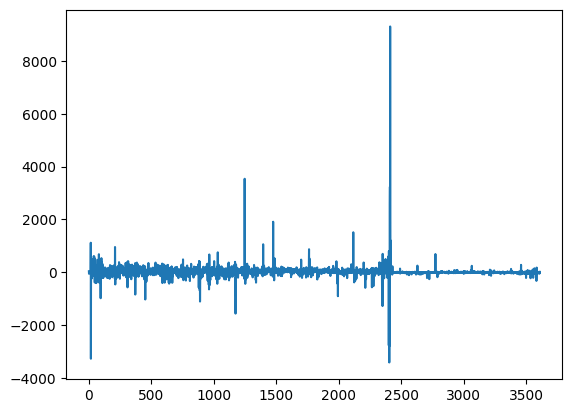

In [26]:
import matplotlib.pyplot as plt

plt.plot(relevance.cpu().numpy()[:-1])
plt.show()

In [27]:
# normalize relevance between [-1, 1] for plotting
relevance_norm = relevance / relevance.abs().max()

In [16]:
image.size

(2048, 1365)

In [28]:
from transformers.models.qwen2_vl.image_processing_qwen2_vl import smart_resize

patch_size = processor.image_processor.patch_size
spatial_merge_size = model.config.vision_config.spatial_merge_size
image_size = image.size

height_new, width_new = smart_resize(
    width=image_size[0],
    height=image_size[1],
    factor=patch_size * processor.image_processor.merge_size,
    min_pixels=processor.image_processor.size["shortest_edge"],
    max_pixels=processor.image_processor.size["longest_edge"],
)

n_patches_x = width_new // patch_size // spatial_merge_size
n_patches_y = height_new // patch_size // spatial_merge_size

In [29]:
img_mask = (inputs["input_ids"] == processor.image_token_id)
token_mask = (inputs["input_ids"] != processor.image_token_id)

In [30]:
img_mask = img_mask.cpu()
token_mask = token_mask.cpu()

In [31]:
img_mask[0]

tensor([False, False, False,  ..., False, False, False])

In [32]:
token_mask[0]

tensor([True, True, True,  ..., True, True, True])

In [33]:
token_relevance = relevance[token_mask[0]]

In [53]:
token_relevance

tensor([ 40.1333, -53.6897, -29.1555,   4.5715,  27.3859,   5.6649,  -6.4529,
         29.6453,  -0.4191,  -8.4232,  18.7484,  -0.5448,  -5.3291, -26.4251,
          9.6887,   2.0147,   1.4811,  -5.0415,   6.0628,  10.5542,   1.6474,
          2.4285,   1.7765,   4.9971,   3.3194, -37.3926,  -9.8687,   4.7604,
        -43.7382, -23.6228,  19.2953, -12.4930])

In [34]:
relevance_norm.sum()

tensor(9.8124)

In [35]:
token_relevance.sum()

tensor(-68.4206)

In [40]:
from einops import rearrange

idx = 0
n_patches = (n_patches_x, n_patches_y)

img_relevance = rearrange(
            relevance_norm[img_mask[idx]],  # (n_patches_x * n_patches_y, dim)
            "(h w) -> w h",
            w=n_patches[0],
            h=n_patches[1],
        )  # (n_patches_x, n_patches_y, dim)


In [41]:
img_relevance.sum()

tensor(9.8197)

In [42]:
import numpy as np
from PIL import Image

# Convert the image to an array
img_array = np.array(image.convert("RGBA"))  # (height, width, channels)

similarity_map_image = Image.fromarray((img_relevance.cpu().numpy() * 255).astype("uint8")).resize(
        image.size, Image.Resampling.BICUBIC
)

In [84]:
image.size

(2048, 1365)

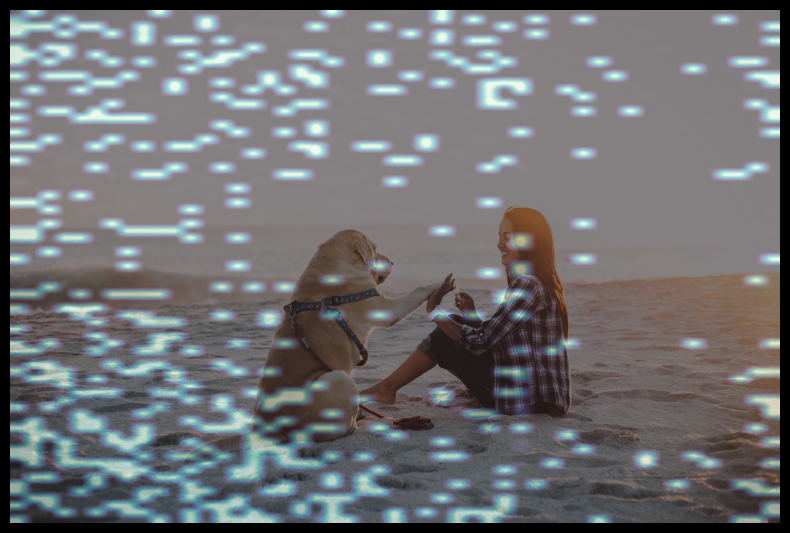

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

figsize= (8,8)
show_colorbar = False
# Create the figure
with plt.style.context("dark_background"):
    fig, ax = plt.subplots(figsize=figsize)

    ax.imshow(img_array)
    im = ax.imshow(
        similarity_map_image,
        cmap=sns.color_palette("mako", as_cmap=True),
        alpha=0.5,
    )

    if show_colorbar:
        fig.colorbar(im)
    ax.set_axis_off()
    fig.tight_layout()

In [44]:
import numpy as np

input_ids = inputs["input_ids"]

# Get the token ID for <|image_pad|>
image_token_id = processor.tokenizer.convert_tokens_to_ids("<|image_pad|>")

if image_token_id == processor.tokenizer.unk_token_id:
    raise ValueError("Could not find the <|image_pad|> token ID!")
else:
    print(f"Found image token ID: {image_token_id} (for '<|image_pad|>')")

# You have these from your LXT run:
# relevance: 1D tensor of relevance scores
# input_ids: 1D tensor of token IDs

relevance_list = relevance_norm.tolist()
input_ids_list = inputs['input_ids'][0].tolist()

# These are your separated outputs
text_tokens_for_heatmap = []
text_relevance_for_heatmap = []
token_list = []

for token_id, score in zip(input_ids_list, relevance_list):
            
    if token_id != image_token_id:
        # --- This is a Text or Special Token ---
        token_list.append(token_id)
        token_str = processor.tokenizer.decode([token_id])
        text_tokens_for_heatmap.append(token_str)
        text_relevance_for_heatmap.append(score)

ids = torch.from_numpy(np.array(token_list)).to(dtype=input_ids.dtype, device=input_ids.device)


Found image token ID: 151655 (for '<|image_pad|>')


In [66]:
ids_1 = input_ids[0][token_mask[0]]

In [67]:
ids_1.shape

torch.Size([32])

In [65]:
input_ids.shape

torch.Size([1, 3609])

In [57]:
input_ids.shape

torch.Size([1, 3609])

In [45]:
torch.cuda.empty_cache()

In [46]:
len(ids)

32

In [47]:
text_relevance_for_heatmap

[0.004313854966312647,
 -0.00577100645750761,
 -0.003133876249194145,
 0.0004913861048407853,
 0.0029436578042805195,
 0.0006089119706302881,
 -0.000693605572450906,
 0.0031865255441516638,
 -4.504645767156035e-05,
 -0.0009053968824446201,
 0.002015237230807543,
 -5.855629569850862e-05,
 -0.000572820717934519,
 -0.002840388799086213,
 0.0010414236458018422,
 0.00021656004537362605,
 0.0001592022890690714,
 -0.0005418981891125441,
 0.0006516785360872746,
 0.0011344527592882514,
 0.00017707367078401148,
 0.00026103388518095016,
 0.00019094807794317603,
 0.0005371289444155991,
 0.00035679881693795323,
 -0.00401926226913929,
 -0.001060769078321755,
 0.0005116844549775124,
 -0.004701343830674887,
 -0.002539178589358926,
 0.002074021380394697,
 -0.0013428454985842109]

In [72]:
output_text = processor.batch_decode(
    ids, skip_special_tokens=False, clean_up_tokenization_spaces=True
)
output_text

['<|im_start|>',
 'system',
 '\n',
 'You',
 ' are',
 ' a',
 ' helpful',
 ' assistant',
 '.',
 '<|im_end|>',
 '\n',
 '<|im_start|>',
 'user',
 '\n',
 '<|vision_start|>',
 '<|vision_end|>',
 'Describe',
 ' the',
 ' main',
 ' scene',
 ' and',
 ' the',
 ' object',
 ' being',
 ' pointed',
 ' at',
 '.',
 '<|im_end|>',
 '\n',
 '<|im_start|>',
 'assistant',
 '\n']

In [73]:
len(output_text)

32

In [50]:
token_relevance.shape

torch.Size([32])

In [75]:
len(text_relevance_for_heatmap)

32

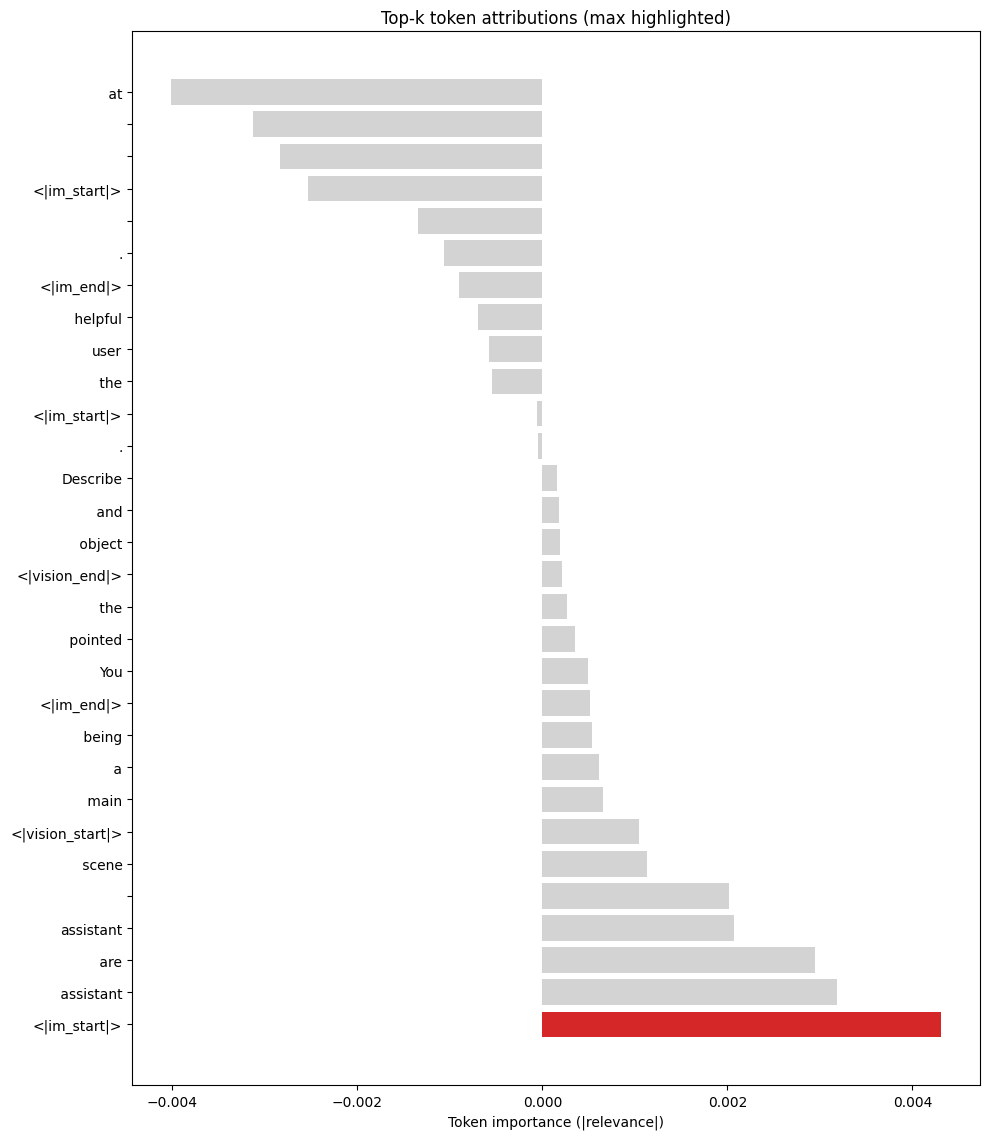

In [51]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# Inputs you already have
scores = torch.tensor(text_relevance_for_heatmap)  # 1D, same length

# "Importance": abs by default (signed scores → magnitude)
imp = scores
idx_max = int(torch.argmax(imp))

# Keep it readable: show top-k (optional)
k = min(30, len(output_text))
top_idx = torch.topk(imp, k).indices.tolist()[::-1]  # highest → lowest
top_output_text = [output_text[i] for i in top_idx]
top_imp    = imp[top_idx].numpy()

# Colors: grey for all, one highlighted
colors = ['lightgray'] * k
colors[top_idx.index(idx_max)] = 'tab:red'  # color only the most important

plt.figure(figsize=(10, 0.35*k + 1))
y = np.arange(k)
plt.barh(y, top_imp, color=colors)
plt.yticks(y, top_output_text)
plt.gca().invert_yaxis()
plt.xlabel('Token importance (|relevance|)')
plt.title('Top-k token attributions (max highlighted)')
plt.tight_layout()
plt.show()


In [52]:
from IPython.display import display, HTML

# --- Assume you have your 'tokens' list and 'relevance' tensor ---

def colorize_tokens(tokens, scores):
    """Generates an HTML string with colored token backgrounds."""
    html_string = ""
    # Normalize scores for color mapping
    scores = torch.from_numpy(np.array(scores))
    scores = scores / scores.abs().max()

    for token, score in zip(tokens, scores):
        # Use blue for positive relevance, red for negative
        if score > 0:
            # Alpha (opacity) is proportional to the score
            color = f"rgba(0, 0, 255, {score:.2f})"
        else:
            # Use the absolute value for opacity
            color = f"rgba(255, 0, 0, {abs(score):.2f})"

        # Add a space after each token for readability
        html_string += f'<span style="background-color: {color};">{token}</span> '

    return html_string

# Generate the HTML
html_output = colorize_tokens(output_text, text_relevance_for_heatmap)

# Display it in the notebook
print("Token Relevance:")
display(HTML(html_output))

Token Relevance:


## ColQwen

In [1]:
import torch
from PIL import Image
from transformers.utils.import_utils import is_flash_attn_2_available

from colpali_engine.models import ColQwen2_5, ColQwen2_5_Processor

In [2]:


model = ColQwen2_5.from_pretrained(
        "vidore/colqwen2.5-v0.2",
        torch_dtype=torch.bfloat16,
        device_map="cuda:0",  # or "mps" if on Apple Silicon
        attn_implementation=None, #"flash_attention_2" if is_flash_attn_2_available() else None,
    ).eval()
processor = ColQwen2_5_Processor.from_pretrained("vidore/colqwen2.5-v0.2")



Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


In [3]:
import mteb

tasks = mteb.get_tasks(tasks=["VidoreArxivQARetrieval"], task_types=["DocumentUnderstanding"], modalities=["text", "image"], languages=['eng'])

In [4]:
task = tasks[0]
task.load_data()             # ensure data is present

corpus = task.corpus["test"]
queries = task.queries["test"]   # dict[qid] -> text

In [35]:
images = [corpus[i]["image"] for i in range (1)]
quest = [queries[i]["text"] for i in range (1)]

In [36]:
quest[0]

'Based on the graph, what is the impact of correcting for fspec not equal to 1 on the surface density trend?'

In [37]:
# Process the inputs
batch_images = processor.process_images(images).to(model.device)
batch_queries = processor.process_queries(quest).to(model.device)


In [44]:
# Forward pass
with torch.no_grad():
    image_embeddings = model(**batch_images)
    query_embeddings = model(**batch_queries)

scores = processor.score_multi_vector(query_embeddings, image_embeddings)

/home/jky/.conda/envs/jky-vdoc/lib/python3.11/site-packages/torch/utils/checkpoint.py:86: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(


In [45]:
scores

tensor([[27.7500]])

In [77]:
print(model.visual)

Qwen2_5_VisionTransformerPretrainedModel(
  (patch_embed): Qwen2_5_VisionPatchEmbed(
    (proj): Conv3d(3, 1280, kernel_size=(2, 14, 14), stride=(2, 14, 14), bias=False)
  )
  (rotary_pos_emb): Qwen2_5_VisionRotaryEmbedding()
  (blocks): ModuleList(
    (0-31): 32 x Qwen2_5_VLVisionBlock(
      (norm1): Qwen2RMSNorm((1280,), eps=1e-06)
      (norm2): Qwen2RMSNorm((1280,), eps=1e-06)
      (attn): Qwen2_5_VLVisionAttention(
        (qkv): Linear(in_features=1280, out_features=3840, bias=True)
        (proj): Linear(in_features=1280, out_features=1280, bias=True)
      )
      (mlp): Qwen2_5_VLMLP(
        (gate_proj): Linear(in_features=1280, out_features=3420, bias=True)
        (up_proj): Linear(in_features=1280, out_features=3420, bias=True)
        (down_proj): Linear(in_features=3420, out_features=1280, bias=True)
        (act_fn): SiLU()
      )
    )
  )
  (merger): Qwen2_5_VLPatchMerger(
    (ln_q): Qwen2RMSNorm((1280,), eps=1e-06)
    (mlp): Sequential(
      (0): Linear(in_fea

## XAI methods

In [ ]:
text_tokens = []
text_relevance_scores = []
image_patch_relevance_scores = []

input_ids_list = inputs['input_ids'][0].tolist()
relevance_list = relevance.tolist()
image_token_id = processor.tokenizer.image_token_id

patch_index = 0
for i, token_id in enumerate(input_ids_list):
    current_relevance = relevance_list[i]
    
    if token_id == image_token_id:
        # This is an image patch
        image_patch_relevance_scores.append((patch_index, current_relevance))
        
        # For visualization, you might want a placeholder
        text_tokens.append(f"[PATCH_{patch_index}]")
        text_relevance_scores.append(current_relevance)
        patch_index += 1
        
    else:
        # This is a text token
        token_str = processor.tokenizer.decode([token_id])
        text_tokens.append(token_str)
        text_relevance_scores.append(current_relevance)

# 1. For text attribution:
# You can now plot the text relevance just like in the example
print("Text Attributions:")
for token, score in zip(text_tokens, text_relevance_scores):
    print(f"{token}: {score:.4f}")

# You can use `pdf_heatmap` with `text_tokens` and `text_relevance_scores`
# pdf_heatmap(text_tokens, text_relevance_scores, path='qwen_vl_heatmap.pdf')


# 2. For image attribution:
# `image_patch_relevance_scores` is a list of (index, relevance) tuples
# The indices 0, 1, 2... correspond to the image patches in order.
print("\nImage Patch Attributions:")
print(image_patch_relevance_scores)

# To visualize this, you must reshape the 1D patch relevance list
# back into the 2D grid of the vision transformer.
# Example: If the vision tower uses 14x14 patches (num_patches=196)
num_patches = len(image_patch_relevance_scores)
grid_size = int(num_patches**0.5) # Assumes a square grid

if grid_size * grid_size == num_patches:
    image_heatmap = torch.zeros(grid_size, grid_size)
    for idx, score in image_patch_relevance_scores:
        row = idx // grid_size
        col = idx % grid_size
        image_heatmap[row, col] = score
    
    # You can now plot this `image_heatmap` (e.g., using matplotlib)
    # and overlay it on the original image.
    print(f"\nImage Relevance Grid ({grid_size}x{grid_size}):")
    print(image_heatmap)
else:
    print("\nCould not determine a square grid for image patch visualization.")

In [ ]:
model.forward()

## LXT

## Attention Rollout

### Draft

In [ ]:
import torch
from torch.nn.modules import Module
from zennit.attribution import Attributor
from zennit.composites import LayerMapComposite
from zennit.core import RemovableHandleList, RemovableHandle, Hook

# --- DEPENDENCY CLASSES (from previous prompts) ---

class HookWithKwargs(Hook):
    '''Base class for hooks that supports kwargs in forward hooks.'''
    def __init__(self):
        super().__init__()
        self.stored_kwargs = None
    
    def pre_forward(self, module, input, kwargs):
        return super().pre_forward(module, input), kwargs

    def forward(self, module, input, kwargs, output):
        '''Forward hook to save module in-/outputs.'''
        self.stored_tensors['input'] = input
        self.stored_kwargs = kwargs

    def register(self, module):
        '''Register this instance by registering all hooks to the supplied module.'''
        return RemovableHandleList([
            RemovableHandle(self),
            module.register_forward_pre_hook(self.pre_forward, with_kwargs=True),
            module.register_forward_hook(self.post_forward),
            module.register_forward_hook(self.forward, with_kwargs=True),
        ])

class HFSavingAttention(HookWithKwargs):
    """
    Hook for Hugging Face attention modules. Saves the attention weights,
    which are assumed to be the second element of the module's output tuple.
    """
    def __init__(self, saved_name: str = "attn_output_weights"):
        super().__init__()
        self.saved_name = saved_name

    def forward(self, module, input, kwargs, output):
        # HF attention modules typically return (hidden_states, attention_probs, ...)
        # We save the attention_probs at index 1.
        self.stored_tensors[self.saved_name] = output[1]



In [ ]:
 #--- THE NEW, IMPROVED ATTRIBUTOR ---

class HFAttentionAttributorV2(Attributor):
    """
    An Attributor for Hugging Face models that accept a dictionary of keyword arguments.
    """
    def __init__(self, model: Module, hf_attention_modules: tuple):
        layer_map = [
            (module_class, HFSavingAttention())
            for module_class in hf_attention_modules
        ]
        composite = LayerMapComposite(layer_map=layer_map)
        super().__init__(model, composite, None)

    def forward(self, input: dict, attr_output_fn=None):
        """
        Performs a forward pass using a dictionary of inputs.

        Args:
            input (dict): A dictionary containing all necessary inputs for the model,
                                 e.g., {'input_ids': ..., 'pixel_values': ...}.
        """
        # if not isinstance(input, dict):
        #     raise TypeError("Input must be a dictionary of model arguments.")
            
        # Create a copy to avoid modifying the user's original dictionary
        kwargs = dict(input)
        
        # Ensure the model is called in a way that returns attention scores
        kwargs["output_attentions"] = True
        
        # Run the forward pass, unpacking the dictionary into keyword arguments
        _ = self.model(**kwargs)

        # Collect the stored attention weights from all the hooks
        attn_output_weights_all = [
            hook_ref.stored_tensors[hook_ref.saved_name]
            for hook_ref in self.composite.hook_refs
        ]
        
        return tuple(attn_output_weights_all)

In [ ]:
import torch
import torch.nn.functional as F
from torch.nn.modules import Module
from zennit.attribution import Attributor
from contextlib import contextmanager

# --- Step 1: A global storage for our captured tensors ---
ATTENTION_MAPS_STORAGE = []

# --- Step 2: The custom softmax function that saves its output ---
original_softmax = F.softmax

def patched_softmax(input, *args, **kwargs):
    # This is the attention weights tensor after softmax is applied
    result = original_softmax(input, *args, **kwargs)
    # We save a clone to avoid issues with in-place operations later
    ATTENTION_MAPS_STORAGE.append(result.clone())
    return result

# --- Step 3: The final Attributor that applies the monkey-patch ---
class HFAttentionAttributorV7(Attributor):
    """
    An Attributor that monkey-patches the functional softmax call within
    the forward pass of target attention modules. This is the most robust
    method for custom models that do not use nn.Softmax modules.
    """
    def __init__(self, model: Module, hf_attention_modules: tuple):
        self.model = model
        self.target_modules = []
        for module in model.modules():
            if isinstance(module, hf_attention_modules):
                self.target_modules.append(module)
        
        if not self.target_modules:
            print("⚠️ WARNING: No target attention modules were found.")
        else:
            print(f"✅ Found {len(self.target_modules)} target attention modules to patch.")

    @contextmanager
    def patch_softmax(self):
        """A context manager to safely apply and remove the patch."""
        try:
            # Replace the softmax function in the functional API
            F.softmax = patched_softmax
            yield
        finally:
            # ALWAYS restore the original function
            F.softmax = original_softmax

    def forward(self, model_inputs):
        # Clear any previously stored maps
        ATTENTION_MAPS_STORAGE.clear()
        
        kwargs = dict(model_inputs)
        kwargs["output_attentions"] = True # Keep this for good measure

        # Apply the patch only during the forward pass
        with self.patch_softmax():
            with torch.no_grad():
                _ = self.model(**kwargs)
        
        return tuple(ATTENTION_MAPS_STORAGE)



In [ ]:
# --- Step 4: Your setup code (remains the same) ---
# (Find the dynamic classes Qwen2_5_VLAttention, Qwen2_5_VLVisionAttention)
# (Load model, processor, and create model_inputs)
from transformers.models.qwen2_5_vl.modeling_qwen2_5_vl import Qwen2_5_VLVisionAttention, Qwen2_5_VLAttention

# --- Step 5: Use the new Attributor ---
hf_attributor = HFAttentionAttributorV7(
    model,
    hf_attention_modules=(Qwen2_5_VLAttention, Qwen2_5_VLVisionAttention)
)

attention_maps = hf_attributor.forward(batch_queries)

# --- Step 6: Inspect the final results ---
if not attention_maps or all(m is None for m in attention_maps):
     print("\n❌ Failed: The returned tuple is still empty.")
else:
    print(f"\n✅ Success! Extracted attention maps from {len(attention_maps)} layers.")
    for i, att_map in enumerate(attention_maps):
        if att_map is not None:
            # The shape should be (batch, heads, seq_len, seq_len)
            print(f"Layer {i+1} Attention Map Shape: {att_map.shape}")
        else:
            print(f"Layer {i+1} is None.")

✅ Found 68 target attention modules to patch.

--- Debug Hook Triggered ---
Module: Qwen2_5_VLAttention
Output Type: <class 'tuple'>
Output is a sequence of length 3
  - Item 0: Tensor with shape torch.Size([5, 37, 2048]) and dtype torch.bfloat16
  - Item 1: Type <class 'NoneType'>
  - Item 2: Type <class 'NoneType'>
--- End Debug Hook ---


❌ Failed: The returned tuple is still empty.


In [ ]:
# For ColQwen, we must identify its specific Self-Attention module.
# By inspecting the model architecture or source code, we find it is Qwen2MoeSelfAttention.
from transformers.models.qwen2_5_vl.modeling_qwen2_5_vl import Qwen2_5_VLVisionAttention, Qwen2_5_VLAttention



# --- USING THE NEW ATTRIBUTOR ---

# 1. Instantiate the attributor with the correct attention module class
hf_attributor = HFAttentionAttributorV2(
    model,
    hf_attention_modules=(Qwen2_5_VLAttention,)
)

In [ ]:
type(batch_queries)

transformers.feature_extraction_utils.BatchFeature

In [ ]:
hf_attention_modules=(Qwen2_5_VLAttention,)

layer_map = [
            (module_class, HFSavingAttention())
            for module_class in hf_attention_modules
        ]

In [ ]:
layer_map

[(transformers.models.qwen2_5_vl.modeling_qwen2_5_vl.Qwen2_5_VLAttention,
  <__main__.HFSavingAttention at 0x7c35775b9350>)]

In [ ]:
# 2. Pass the entire `model_inputs` dictionary to the forward method
attention_maps = hf_attributor.forward(batch_queries)

In [ ]:
attention_maps

()

In [ ]:
for name, module in model.named_modules():
    if isinstance(module, Qwen2_5_VLAttention):
        print(name)
    if isinstance(module, Qwen2_5_VLVisionAttention):
        print(name)
        # found_attention_classes.add(module.__class__)

visual.blocks.0.attn
visual.blocks.1.attn
visual.blocks.2.attn
visual.blocks.3.attn
visual.blocks.4.attn
visual.blocks.5.attn
visual.blocks.6.attn
visual.blocks.7.attn
visual.blocks.8.attn
visual.blocks.9.attn
visual.blocks.10.attn
visual.blocks.11.attn
visual.blocks.12.attn
visual.blocks.13.attn
visual.blocks.14.attn
visual.blocks.15.attn
visual.blocks.16.attn
visual.blocks.17.attn
visual.blocks.18.attn
visual.blocks.19.attn
visual.blocks.20.attn
visual.blocks.21.attn
visual.blocks.22.attn
visual.blocks.23.attn
visual.blocks.24.attn
visual.blocks.25.attn
visual.blocks.26.attn
visual.blocks.27.attn
visual.blocks.28.attn
visual.blocks.29.attn
visual.blocks.30.attn
visual.blocks.31.attn
language_model.layers.0.self_attn
language_model.layers.1.self_attn
language_model.layers.2.self_attn
language_model.layers.3.self_attn
language_model.layers.4.self_attn
language_model.layers.5.self_attn
language_model.layers.6.self_attn
language_model.layers.7.self_attn
language_model.layers.8.self_attn


In [ ]:
# --- Diagnostic Script ---
import torch
# Your model and processor loading code...
# ...

# --- Step 1: Find the actual module classes in the loaded model ---
# It's crucial to get the class objects directly from the model instance,
# as they were created dynamically by the remote code.

Qwen2_5_VLAttention = None
for module in model.modules():
    if module.__class__.__name__ == "Qwen2_5_VLAttention":
        Qwen2_5_VLAttention = module.__class__
        break

if Qwen2_5_VLAttention is None:
    raise RuntimeError("Could not find the 'Qwen2_5_VLAttention' class in the model.")
else:
    print(f"✅ Found the class: {Qwen2_5_VLAttention}")

# --- Step 2: Define a simple debug hook ---
def debug_hook(module, input, output):
    print("\n--- Debug Hook Triggered ---")
    print(f"Module: {module.__class__.__name__}")
    print(f"Output Type: {type(output)}")

    if isinstance(output, tuple) or isinstance(output, list):
        print(f"Output is a sequence of length {len(output)}")
        for i, item in enumerate(output):
            if torch.is_tensor(item):
                print(f"  - Item {i}: Tensor with shape {item.shape} and dtype {item.dtype}")
            else:
                print(f"  - Item {i}: Type {type(item)}")
    elif torch.is_tensor(output):
        print(f"Output is a single tensor with shape {output.shape}")
    else:
        # It could be a custom dataclass like BaseModelOutputWithPast
        print(f"Output is an object. Attributes: {dir(output)}")

    print("--- End Debug Hook ---\n")
    # We only need to run this once, so we'll remove the hook immediately.
    hook_handle.remove()

# --- Step 3: Attach the hook and run one forward pass ---
# Find the first instance of the target module to attach our hook
target_module = None
for name, module in model.named_modules():
    if isinstance(module, Qwen2_5_VLAttention):
        target_module = module
        print(f"Attaching debug hook to module: {name}")
        break

if target_module:
    hook_handle = target_module.register_forward_hook(debug_hook)
    
    # Run a forward pass to trigger the hook
    with torch.no_grad():
        _ = model(**batch_queries, output_attentions=True)
else:
    print("⚠️ Could not find an instance of the target module to attach the hook.")

✅ Found the class: <class 'transformers.models.qwen2_5_vl.modeling_qwen2_5_vl.Qwen2_5_VLAttention'>
Attaching debug hook to module: language_model.layers.0.self_attn

--- Debug Hook Triggered ---
Module: Qwen2_5_VLAttention
Output Type: <class 'tuple'>
Output is a sequence of length 3
  - Item 0: Tensor with shape torch.Size([5, 37, 2048]) and dtype torch.bfloat16
  - Item 1: Type <class 'NoneType'>
  - Item 2: Type <class 'NoneType'>
--- End Debug Hook ---


--- Debug Hook Triggered ---
Module: Qwen2_5_VLAttention
Output Type: <class 'tuple'>
Output is a sequence of length 3
  - Item 0: Tensor with shape torch.Size([5, 37, 2048]) and dtype torch.bfloat16
  - Item 1: Type <class 'NoneType'>
  - Item 2: Type <class 'NoneType'>
--- End Debug Hook ---



In [30]:
from transformers.models.qwen2_5_vl import modeling_qwen2_5_vl

for name, m in model.named_modules():
    if "attn" in name.lower() and hasattr(m, "forward"):
        if isinstance(m, modeling_qwen2_5_vl.Qwen2_5_VLAttention):
            print(name)
        if isinstance(m, modeling_qwen2_5_vl.Qwen2_5_VLVisionAttention):
            print(name)

visual.blocks.0.attn
visual.blocks.1.attn
visual.blocks.2.attn
visual.blocks.3.attn
visual.blocks.4.attn
visual.blocks.5.attn
visual.blocks.6.attn
visual.blocks.7.attn
visual.blocks.8.attn
visual.blocks.9.attn
visual.blocks.10.attn
visual.blocks.11.attn
visual.blocks.12.attn
visual.blocks.13.attn
visual.blocks.14.attn
visual.blocks.15.attn
visual.blocks.16.attn
visual.blocks.17.attn
visual.blocks.18.attn
visual.blocks.19.attn
visual.blocks.20.attn
visual.blocks.21.attn
visual.blocks.22.attn
visual.blocks.23.attn
visual.blocks.24.attn
visual.blocks.25.attn
visual.blocks.26.attn
visual.blocks.27.attn
visual.blocks.28.attn
visual.blocks.29.attn
visual.blocks.30.attn
visual.blocks.31.attn
language_model.layers.0.self_attn
language_model.layers.1.self_attn
language_model.layers.2.self_attn
language_model.layers.3.self_attn
language_model.layers.4.self_attn
language_model.layers.5.self_attn
language_model.layers.6.self_attn
language_model.layers.7.self_attn
language_model.layers.8.self_attn


In [ ]:
from torch.nn import MultiheadAttention
from torch.nn.modules import Module
from zennit.attribution import Attributor
from zennit.composites import LayerMapComposite

from pnpxai.explainers.attentions.rules import SavingAttention
from pnpxai.explainers.attentions.module_converters import default_attention_converters
from pnpxai.explainers.utils import _format_to_tuple


class SavingAttentionAttributor(Attributor):
    def __init__(self, model: Module):
        layer_map = [(MultiheadAttention, SavingAttention())]
        composite = LayerMapComposite(layer_map=layer_map, canonizers=default_attention_converters)
        super().__init__(model, composite, None)    

    
    def forward(self, input, attr_output_fn):
        input = _format_to_tuple(input)
        _ = self.model(*input)
        attn_output_weights_all = [
            hook_ref.stored_tensors[hook_ref.saved_name]
            for hook_ref in self.composite.hook_refs
        ]
        return tuple(attn_output_weights_all)

In [21]:
from pnpxai.explainers.attention_rollout import AttentionRollout

explainer = AttentionRollout(model=model)